<table align="left">
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/glasslego/ml-deep-learning-study/blob/main/src/ml_example_notebook/wine_classification.ipynb"><img src="https://www.tensorflow.org/images/colab_logo_32px.png" />구글 코랩에서 실행하기</a>
  </td>
</table>

# 실습: 와인 품질 분류 예측

## 분류(Classification) 알고리즘 핵심 개념:

### 1. 로지스틱 회귀 (Logistic Regression):
- 선형 회귀 + 시그모이드 함수로 확률 예측
- P(y=1|X) = 1 / (1 + e^(-β₀ - β₁x₁ - ... - βₙxₙ))
- 손실 함수: 로그 손실(Log Loss) = -Σ[y*log(p) + (1-y)*log(1-p)]
- 선형 결정 경계, 확률적 출력 제공

### 2. 결정 트리 (Decision Tree):
- 규칙 기반 분할로 의사결정 구조 생성
- 분할 기준: 지니 불순도, 엔트로피, 정보 이득
- 지니 불순도 = 1 - Σ(pᵢ²), 엔트로피 = -Σ(pᵢ log₂ pᵢ)
- 비선형 결정 경계, 해석 가능성 우수

### 분류 성능 평가 지표:
- **정확도(Accuracy)**: (TP + TN) / (TP + TN + FP + FN)
- **정밀도(Precision)**: TP / (TP + FP) - 양성 예측 중 실제 양성 비율
- **재현율(Recall)**: TP / (TP + FN) - 실제 양성 중 예측한 양성 비율
- **F1-Score**: 2 * (Precision * Recall) / (Precision + Recall)
- **ROC AUC**: 다양한 임계값에서의 성능 종합 평가

In [1]:
# 필요한 라이브러리 import
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree

warnings.filterwarnings("ignore")
print("✅ 라이브러리 로드 완료!")

# 한글 폰트 설정 (Mac의 경우)
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

✅ 라이브러리 로드 완료!


## 1. 와인 데이터셋 로드 및 탐색적 데이터 분석

### Wine Dataset 특징:
- **3개 클래스**: Class 0, 1, 2 (와인 품종)
- **13개 피처**: 알코올 도수, 말산, 애쉬, 알칼리도 등 화학적 성분
- **178개 샘플**, 균형잡힌 클래스 분포

In [2]:
print("=== 와인 데이터셋 탐색 ===")

# 데이터 로드
wine = load_wine()
X, y = wine.data, wine.target

# DataFrame 생성
df = pd.DataFrame(X, columns=wine.feature_names)
df["target"] = y
df["target_name"] = df["target"].map(
    {0: wine.target_names[0], 1: wine.target_names[1], 2: wine.target_names[2]}
)

print(f"데이터 형태: {df.shape}")
print(f"피처 수: {len(wine.feature_names)}")
print(f"클래스 수: {len(wine.target_names)}")
print(f"클래스명: {wine.target_names}")

# 클래스 분포 확인
print("\n클래스 분포:")
class_counts = df["target"].value_counts().sort_index()
for i, count in enumerate(class_counts):
    print(
        f"  {wine.target_names[i]} (Class {i}): {count}개 ({count / len(df) * 100:.1f}%)"
    )

# 기술 통계
print("\n피처별 기술 통계:")
print(df[wine.feature_names].describe().round(2))

# 결측값 확인
print(f"\n결측값: {df.isnull().sum().sum()}개")

=== 와인 데이터셋 탐색 ===
데이터 형태: (178, 15)
피처 수: 13
클래스 수: 3
클래스명: ['class_0' 'class_1' 'class_2']

클래스 분포:
  class_0 (Class 0): 59개 (33.1%)
  class_1 (Class 1): 71개 (39.9%)
  class_2 (Class 2): 48개 (27.0%)

피처별 기술 통계:
       alcohol  malic_acid     ash  alcalinity_of_ash  magnesium  \
count   178.00      178.00  178.00             178.00     178.00   
mean     13.00        2.34    2.37              19.49      99.74   
std       0.81        1.12    0.27               3.34      14.28   
min      11.03        0.74    1.36              10.60      70.00   
25%      12.36        1.60    2.21              17.20      88.00   
50%      13.05        1.87    2.36              19.50      98.00   
75%      13.68        3.08    2.56              21.50     107.00   
max      14.83        5.80    3.23              30.00     162.00   

       total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
count         178.00      178.00                178.00           178.00   
mean            2.30    

## 2. 와인 데이터 시각화
- 클래스별 피처 분포 비교
- 상관관계 분석
- 주성분 분석을 통한 2D 시각화

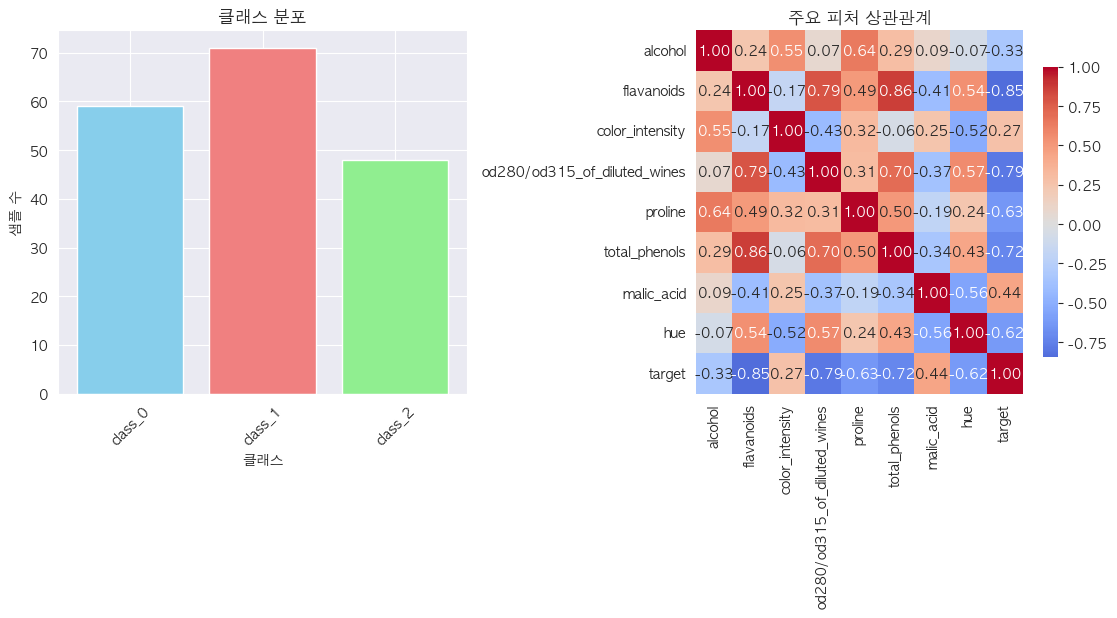

In [5]:
fig = plt.figure(figsize=(24, 16))

# 1. 클래스 분포
plt.subplot(3, 4, 1)
class_counts = df["target"].value_counts().sort_index()
colors = ["skyblue", "lightcoral", "lightgreen"]
plt.bar(range(len(wine.target_names)), class_counts.values, color=colors)
plt.xlabel("클래스")
plt.ylabel("샘플 수")
plt.title("클래스 분포")
plt.xticks(range(len(wine.target_names)), wine.target_names, rotation=45)

# 2. 상관관계 히트맵
plt.subplot(3, 4, 2)
# 피처 개수가 많으므로 상위 8개 중요 피처만 선택
important_features = [
    "alcohol",
    "flavanoids",
    "color_intensity",
    "od280/od315_of_diluted_wines",
    "proline",
    "total_phenols",
    "malic_acid",
    "hue",
]
if all(feature in df.columns for feature in important_features):
    corr_subset = df[important_features + ["target"]].corr()
    sns.heatmap(
        corr_subset,
        annot=True,
        cmap="coolwarm",
        center=0,
        fmt=".2f",
        cbar_kws={"shrink": 0.8},
    )
    plt.title("주요 피처 상관관계")

plt.tight_layout()
plt.show()

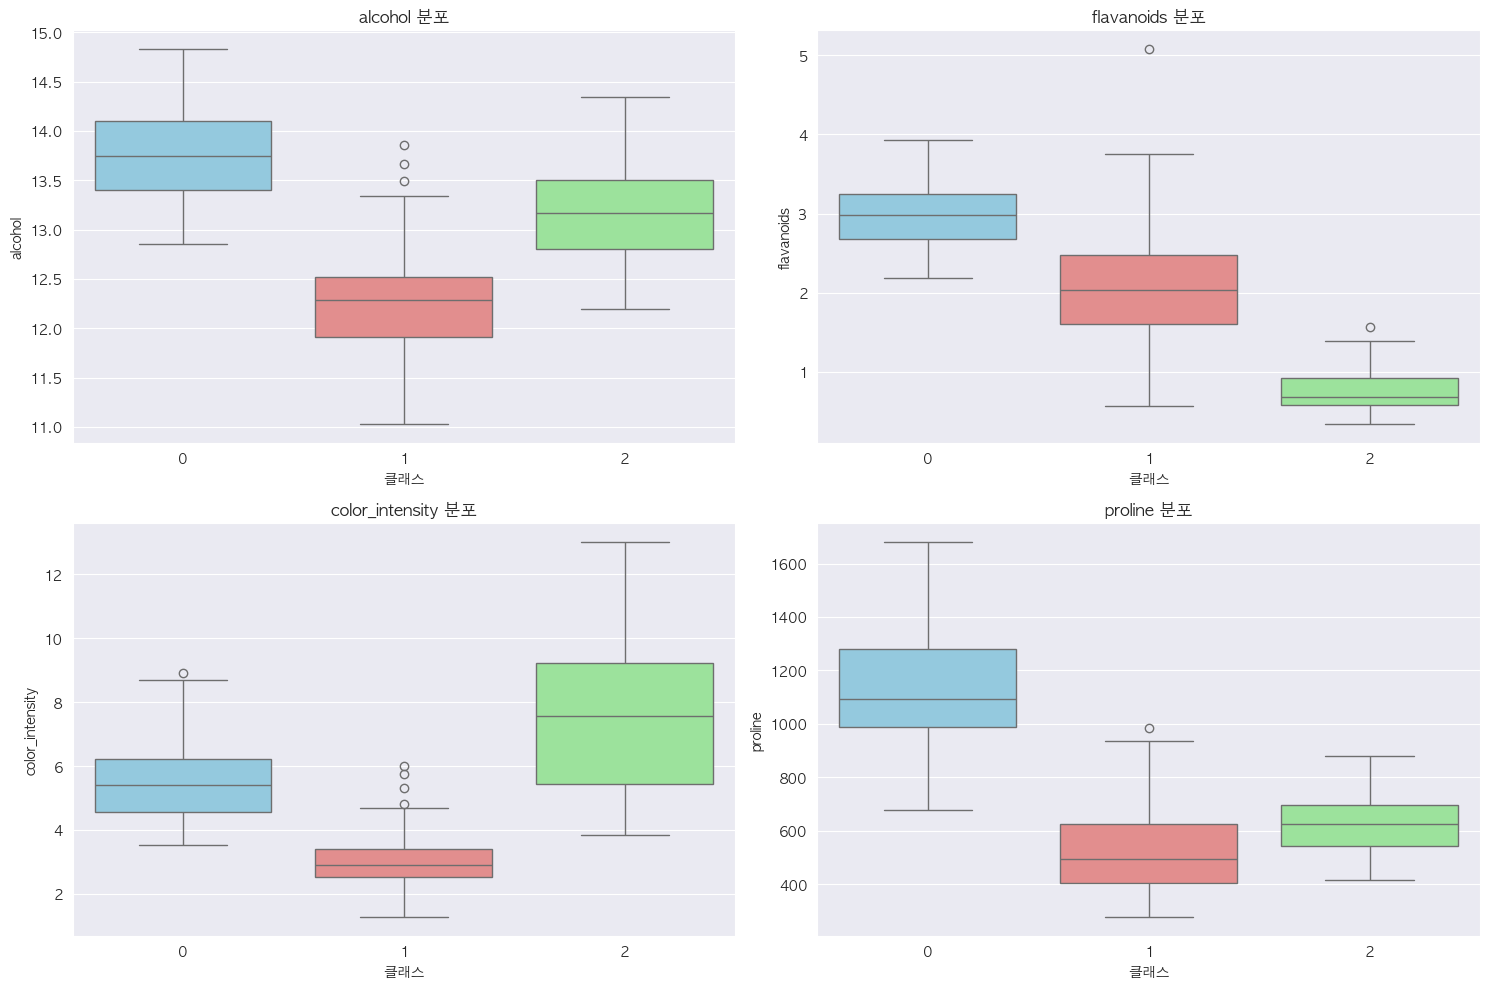

In [6]:
# 3-6. 주요 피처별 클래스 분포 (박스플롯)
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
key_features = ["alcohol", "flavanoids", "color_intensity", "proline"]

for i, feature in enumerate(key_features):
    row, col = i // 2, i % 2
    sns.boxplot(data=df, x="target", y=feature, palette=colors, ax=axes[row, col])
    axes[row, col].set_title(f"{feature} 분포")
    axes[row, col].set_xlabel("클래스")

plt.tight_layout()
plt.show()

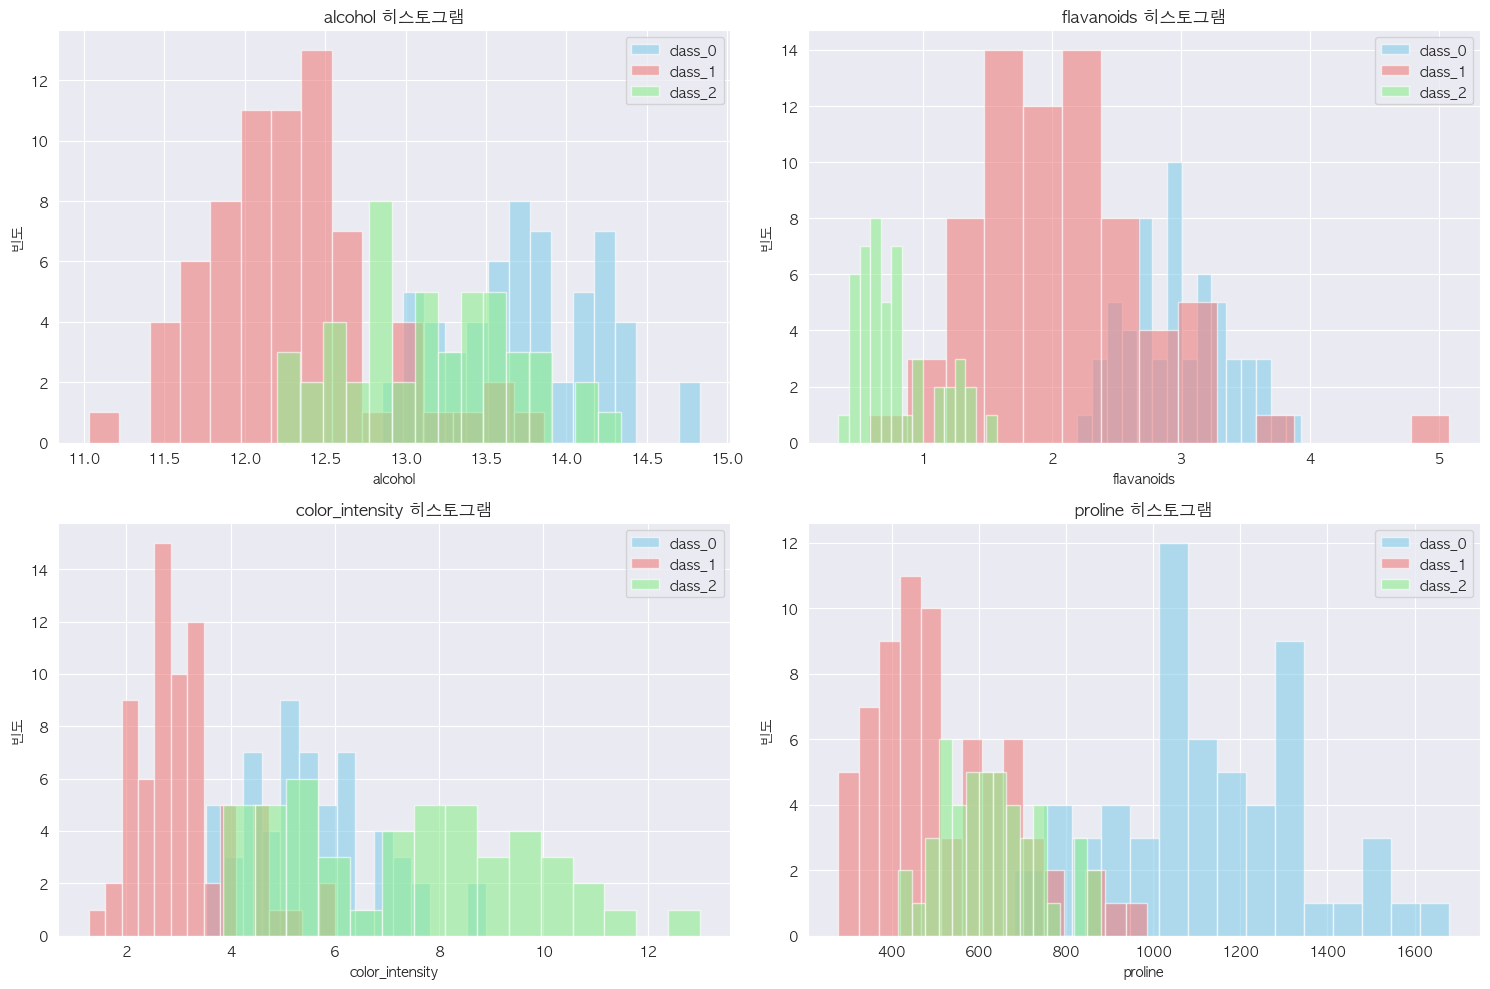

In [7]:
# 7-10. 주요 피처별 히스토그램 (클래스별)
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

for i, feature in enumerate(key_features):
    row, col = i // 2, i % 2
    for class_id in range(3):
        subset = df[df["target"] == class_id][feature]
        axes[row, col].hist(
            subset,
            alpha=0.6,
            label=f"{wine.target_names[class_id]}",
            color=colors[class_id],
            bins=15,
        )
    axes[row, col].set_xlabel(feature)
    axes[row, col].set_ylabel("빈도")
    axes[row, col].set_title(f"{feature} 히스토그램")
    axes[row, col].legend()

plt.tight_layout()
plt.show()

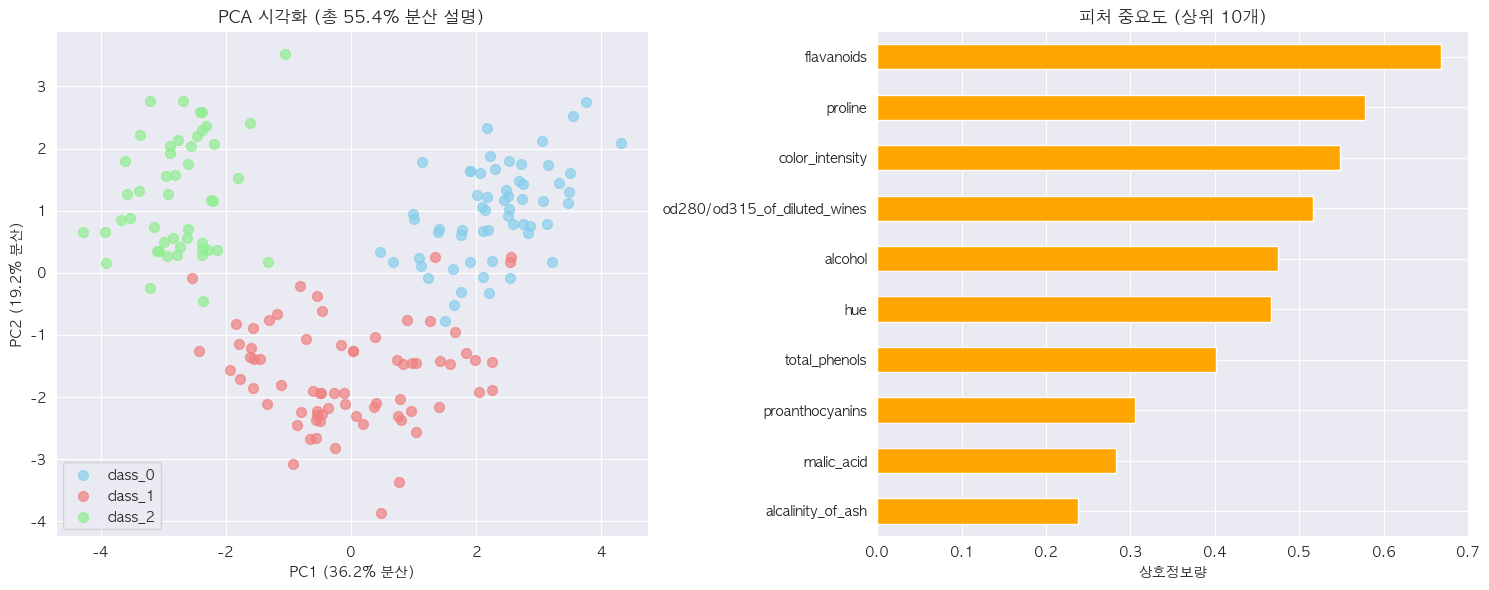

In [8]:
# PCA 2D 시각화 및 피처 중요도
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_classif

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# PCA 2D 시각화
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[wine.feature_names])
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

for class_id in range(3):
    mask = df["target"] == class_id
    ax1.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        c=colors[class_id],
        label=wine.target_names[class_id],
        alpha=0.7,
        s=50,
    )

ax1.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} 분산)")
ax1.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} 분산)")
ax1.set_title(f"PCA 시각화 (총 {pca.explained_variance_ratio_.sum():.1%} 분산 설명)")
ax1.legend()

# 피처 중요도 (상호정보량)
mi_scores = mutual_info_classif(
    df[wine.feature_names], df["target"], random_state=42
)
feature_importance = pd.Series(mi_scores, index=wine.feature_names).sort_values(
    ascending=True
)

# 상위 10개만 표시
top_features = feature_importance.tail(10)
top_features.plot(kind="barh", color="orange", ax=ax2)
ax2.set_xlabel("상호정보량")
ax2.set_title("피처 중요도 (상위 10개)")

plt.tight_layout()
plt.show()

## 3. 여러 분류 모델 구축 및 비교
- **로지스틱 회귀**: 선형 분류기
- **결정 트리**: 비선형, 해석 가능
- **랜덤 포레스트**: 앙상블, 높은 성능

In [9]:
print("\n=== 분류 모델 구축 ===")

# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"학습 데이터: {X_train.shape}")
print(f"테스트 데이터: {X_test.shape}")
print(f"학습 세트 클래스 분포: {np.bincount(y_train)}")
print(f"테스트 세트 클래스 분포: {np.bincount(y_test)}")


=== 분류 모델 구축 ===
학습 데이터: (142, 13)
테스트 데이터: (36, 13)
학습 세트 클래스 분포: [47 57 38]
테스트 세트 클래스 분포: [12 14 10]


In [10]:
# 모델 정의
models = {
    "Logistic Regression": Pipeline(
        [
            ("scaler", StandardScaler()),  # 로지스틱 회귀는 스케일링 필수
            ("classifier", LogisticRegression(random_state=42, max_iter=1000)),
        ]
    ),
    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        max_depth=5,  # 과적합 방지
        min_samples_split=10,
        min_samples_leaf=5,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100, random_state=42, max_depth=5, min_samples_split=10
    ),
}

results = {}
print("\n모델 학습 및 평가:")


모델 학습 및 평가:


In [11]:
for name, model in models.items():
    print(f"\n--- {name} ---")

    # 모델 학습
    model.fit(X_train, y_train)

    # 예측
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # 확률 예측 (ROC 커브용)
    if hasattr(model, "predict_proba"):
        y_test_proba = model.predict_proba(X_test)
    elif hasattr(model.named_steps["classifier"], "predict_proba"):
        y_test_proba = model.predict_proba(X_test)
    else:
        y_test_proba = None

    # 성능 지표 계산
    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)

    # 다중 클래스의 경우 macro 평균 사용
    test_precision = precision_score(y_test, y_test_pred, average="macro")
    test_recall = recall_score(y_test, y_test_pred, average="macro")
    test_f1 = f1_score(y_test, y_test_pred, average="macro")

    # ROC AUC (다중 클래스의 경우 ovr 방식)
    if y_test_proba is not None:
        test_auc = roc_auc_score(y_test, y_test_proba, multi_class="ovr")
    else:
        test_auc = None

    # 교차검증 (더 robust한 평가)
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring="accuracy")

    results[name] = {
        "model": model,
        "train_accuracy": train_accuracy,
        "test_accuracy": test_accuracy,
        "test_precision": test_precision,
        "test_recall": test_recall,
        "test_f1": test_f1,
        "test_auc": test_auc,
        "cv_mean": cv_scores.mean(),
        "cv_std": cv_scores.std(),
        "y_test_pred": y_test_pred,
        "y_test_proba": y_test_proba,
    }

    print(f"  학습 정확도: {train_accuracy:.4f}")
    print(f"  테스트 정확도: {test_accuracy:.4f}")
    print(f"  정밀도: {test_precision:.4f}")
    print(f"  재현율: {test_recall:.4f}")
    print(f"  F1 스코어: {test_f1:.4f}")
    if test_auc:
        print(f"  ROC AUC: {test_auc:.4f}")
    print(f"  CV 정확도: {cv_scores.mean():.4f} (±{cv_scores.std():.4f})")
    print(f"  과적합 정도: {train_accuracy - test_accuracy:.4f}")


--- Logistic Regression ---
  학습 정확도: 1.0000
  테스트 정확도: 0.9722
  정밀도: 0.9778
  재현율: 0.9667
  F1 스코어: 0.9710
  ROC AUC: 1.0000
  CV 정확도: 0.9931 (±0.0138)
  과적합 정도: 0.0278

--- Decision Tree ---
  학습 정확도: 0.9718
  테스트 정확도: 0.9444
  정밀도: 0.9583
  재현율: 0.9444
  F1 스코어: 0.9475
  ROC AUC: 0.9955
  CV 정확도: 0.9160 (±0.0470)
  과적합 정도: 0.0274

--- Random Forest ---
  학습 정확도: 1.0000
  테스트 정확도: 1.0000
  정밀도: 1.0000
  재현율: 1.0000
  F1 스코어: 1.0000
  ROC AUC: 1.0000
  CV 정확도: 0.9862 (±0.0276)
  과적합 정도: 0.0000


## 4. 혼동 행렬(Confusion Matrix) 분석
- 각 클래스별 예측 성능 상세 분석
- 어떤 클래스가 혼동되기 쉬운지 파악


=== 혼동 행렬 분석 ===


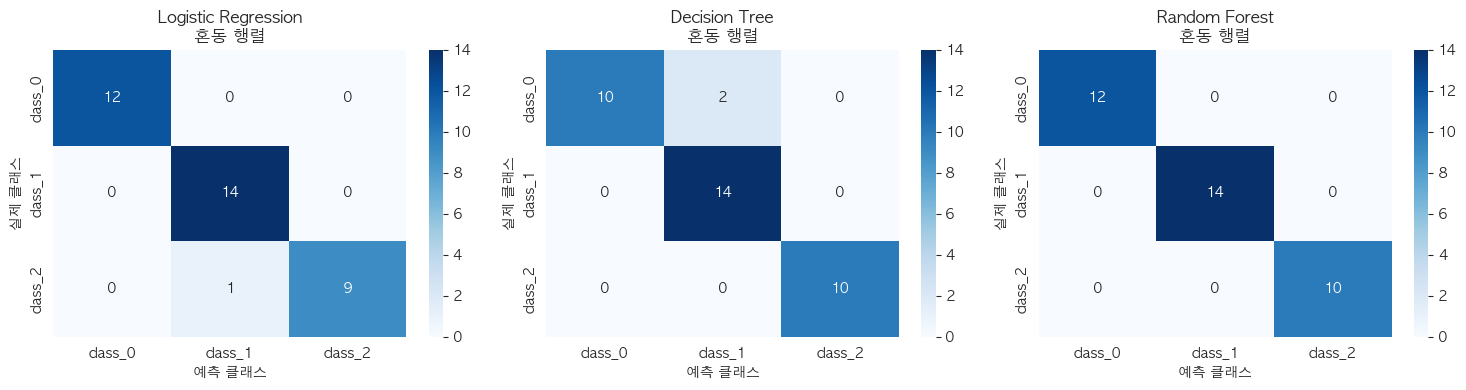

In [12]:
print("\n=== 혼동 행렬 분석 ===")

fig, axes = plt.subplots(1, len(results), figsize=(5 * len(results), 4))
if len(results) == 1:
    axes = [axes]

for idx, (name, result) in enumerate(results.items()):
    cm = confusion_matrix(y_test, result["y_test_pred"])

    # 혼동 행렬 시각화
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=wine.target_names,
        yticklabels=wine.target_names,
        ax=axes[idx],
    )
    axes[idx].set_title(f"{name}\n혼동 행렬")
    axes[idx].set_xlabel("예측 클래스")
    axes[idx].set_ylabel("실제 클래스")

plt.tight_layout()
plt.show()

In [13]:
# 클래스별 성능 분석
for name, result in results.items():
    print(f"\n--- {name} 클래스별 성능 ---")
    print(
        classification_report(
            y_test, result["y_test_pred"], target_names=wine.target_names
        )
    )


--- Logistic Regression 클래스별 성능 ---
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       0.93      1.00      0.97        14
     class_2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36


--- Decision Tree 클래스별 성능 ---
              precision    recall  f1-score   support

     class_0       1.00      0.83      0.91        12
     class_1       0.88      1.00      0.93        14
     class_2       1.00      1.00      1.00        10

    accuracy                           0.94        36
   macro avg       0.96      0.94      0.95        36
weighted avg       0.95      0.94      0.94        36


--- Random Forest 클래스별 성능 ---
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      1

## 5. ROC 커브 분석
- 각 모델의 TPR vs FPR 성능 시각화
- 다중 클래스의 경우 각 클래스별 ROC 커브


=== ROC 커브 분석 ===


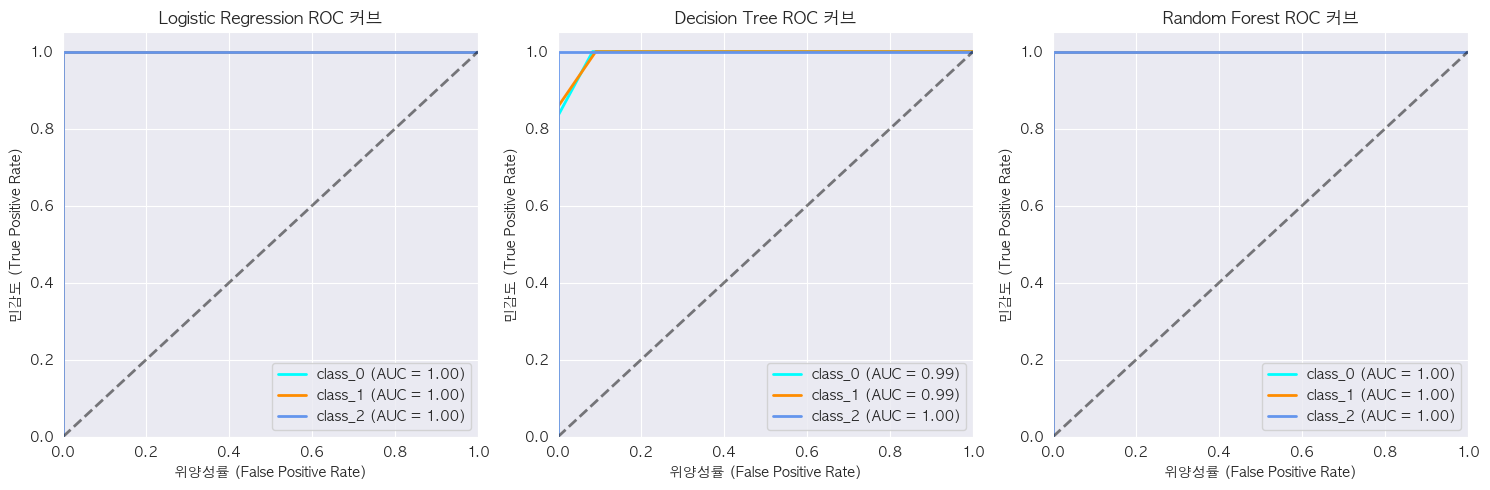

In [14]:
print("\n=== ROC 커브 분석 ===")

from itertools import cycle
from sklearn.preprocessing import label_binarize

# 다중 클래스를 이진 분류로 변환
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
n_classes = y_test_bin.shape[1]

# 색상 설정
colors_roc = cycle(["aqua", "darkorange", "cornflowerblue"])

plt.figure(figsize=(15, 5))

plot_idx = 1
for name, result in results.items():
    if result["y_test_proba"] is None:
        continue

    plt.subplot(1, 3, plot_idx)

    # 각 클래스별 ROC 커브
    for i, color in zip(range(n_classes), colors_roc):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], result["y_test_proba"][:, i])
        auc = roc_auc_score(y_test_bin[:, i], result["y_test_proba"][:, i])

        plt.plot(
            fpr,
            tpr,
            color=color,
            lw=2,
            label=f"{wine.target_names[i]} (AUC = {auc:.2f})",
        )

    # 대각선 (랜덤 분류기)
    plt.plot([0, 1], [0, 1], "k--", lw=2, alpha=0.5)

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("위양성률 (False Positive Rate)")
    plt.ylabel("민감도 (True Positive Rate)")
    plt.title(f"{name} ROC 커브")
    plt.legend(loc="lower right")
    
    plot_idx += 1

plt.tight_layout()
plt.show()

## 6. 결정 트리 모델 해석
- 트리 구조 시각화
- 피처 중요도 분석
- 의사결정 규칙 추출


=== 결정 트리 분석 ===
피처 중요도 (상위 10개):
  color_intensity: 0.4429
  flavanoids: 0.4348
  proline: 0.1183
  proanthocyanins: 0.0040
  alcohol: 0.0000
  malic_acid: 0.0000
  ash: 0.0000
  alcalinity_of_ash: 0.0000
  magnesium: 0.0000
  total_phenols: 0.0000


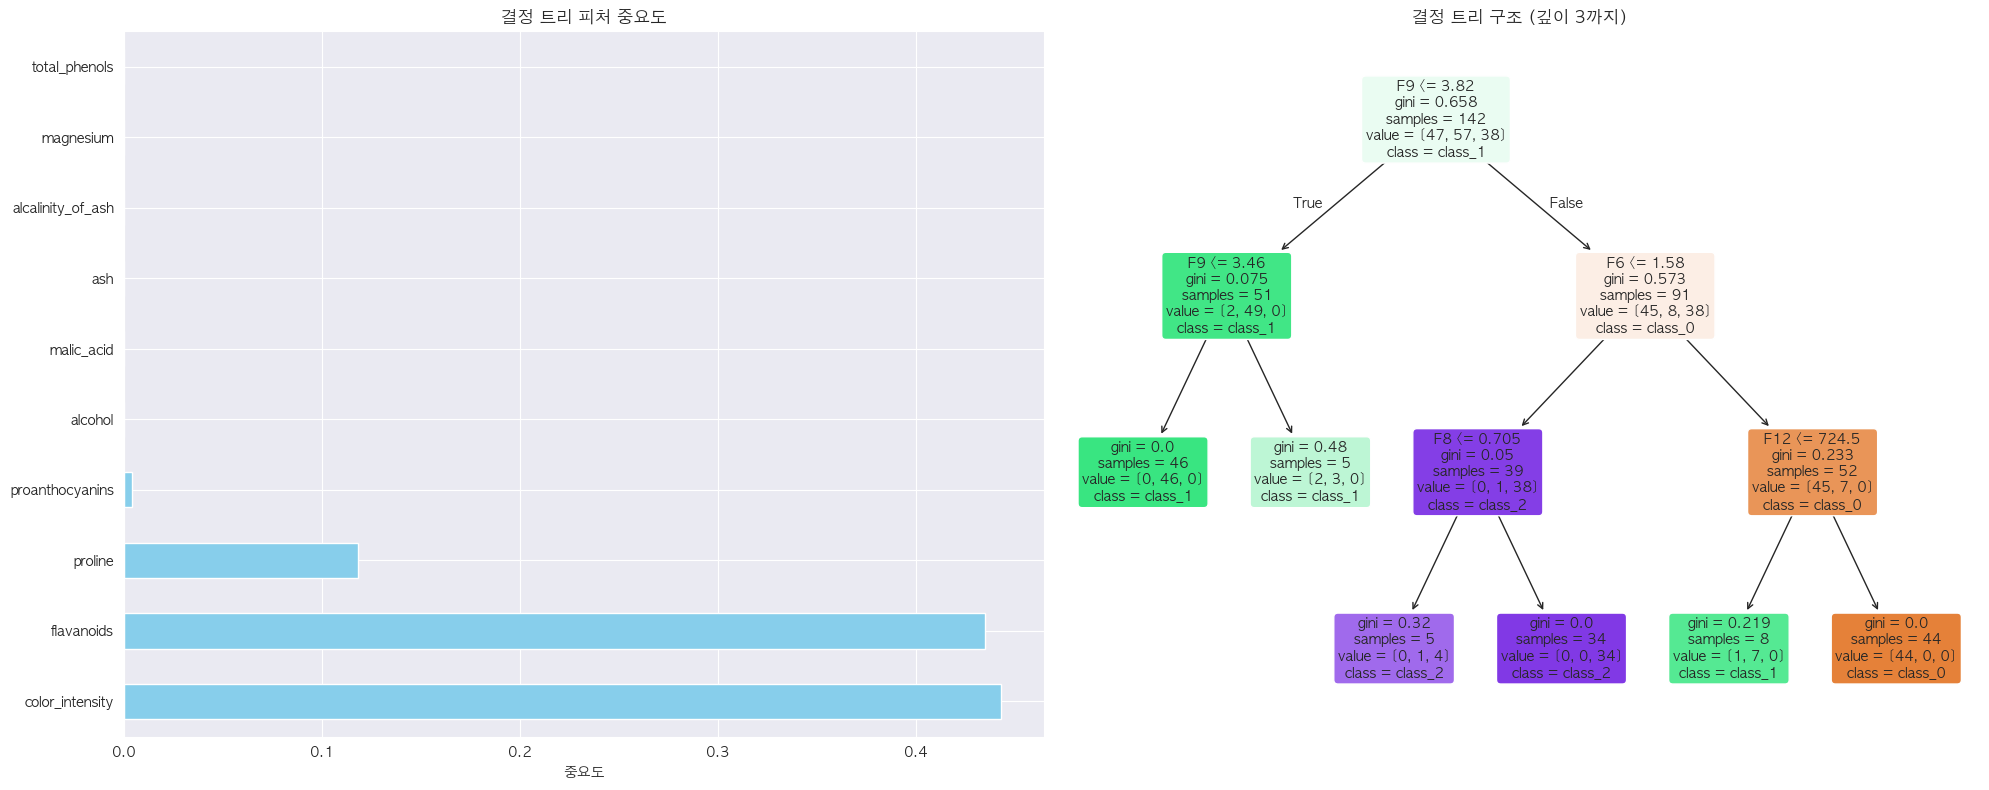


트리 통계:
  최대 깊이: 3
  리프 노드 수: 6
  총 노드 수: 11


In [15]:
if "Decision Tree" in results:
    print("\n=== 결정 트리 분석 ===")

    dt_model = results["Decision Tree"]["model"]

    # 피처 중요도
    feature_importance = pd.Series(
        dt_model.feature_importances_,
        index=wine.feature_names,
    ).sort_values(ascending=False)

    print("피처 중요도 (상위 10개):")
    for feature, importance in feature_importance.head(10).items():
        print(f"  {feature}: {importance:.4f}")

    # 시각화
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

    # 1. 피처 중요도 바 차트
    feature_importance.head(10).plot(kind="barh", ax=ax1, color="skyblue")
    ax1.set_title("결정 트리 피처 중요도")
    ax1.set_xlabel("중요도")

    # 2. 트리 구조 시각화 (최대 깊이 3까지만)
    plot_tree(
        dt_model,
        max_depth=3,
        feature_names=[f"F{i}" for i in range(len(wine.feature_names))],
        class_names=wine.target_names,
        filled=True,
        rounded=True,
        fontsize=10,
        ax=ax2,
    )
    ax2.set_title("결정 트리 구조 (깊이 3까지)")

    plt.tight_layout()
    plt.show()

    # 트리 통계
    print("\n트리 통계:")
    print(f"  최대 깊이: {dt_model.get_depth()}")
    print(f"  리프 노드 수: {dt_model.get_n_leaves()}")
    print(f"  총 노드 수: {dt_model.tree_.node_count}")

## 7. 하이퍼파라미터 튜닝
- Grid Search를 통한 최적 파라미터 탐색
- 교차검증으로 성능 평가

In [16]:
print("\n=== 하이퍼파라미터 튜닝 ===")

# Decision Tree 튜닝
print("Decision Tree 튜닝 중...")
dt_params = {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "criterion": ["gini", "entropy"],
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
)
dt_grid.fit(X_train, y_train)

print(f"최적 파라미터: {dt_grid.best_params_}")
print(f"최적 CV 점수: {dt_grid.best_score_:.4f}")


=== 하이퍼파라미터 튜닝 ===
Decision Tree 튜닝 중...
최적 파라미터: {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 2, 'min_samples_split': 2}
최적 CV 점수: 0.9303


In [17]:
# Random Forest 튜닝
print("\nRandom Forest 튜닝 중...")
rf_params = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 5, 7, 10],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5],
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
)
rf_grid.fit(X_train, y_train)

print(f"최적 파라미터: {rf_grid.best_params_}")
print(f"최적 CV 점수: {rf_grid.best_score_:.4f}")


Random Forest 튜닝 중...
최적 파라미터: {'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
최적 CV 점수: 0.9862


In [18]:
# 튜닝된 모델 성능 비교
tuned_models = {
    "Tuned Decision Tree": dt_grid.best_estimator_,
    "Tuned Random Forest": rf_grid.best_estimator_,
}

print("\n튜닝 후 성능:")
for name, model in tuned_models.items():
    model.fit(X_train, y_train)
    train_score = model.score(X_train, y_train)
    test_score = model.score(X_test, y_test)
    print(f"{name}:")
    print(f"  학습 정확도: {train_score:.4f}")
    print(f"  테스트 정확도: {test_score:.4f}")


튜닝 후 성능:
Tuned Decision Tree:
  학습 정확도: 0.9859
  테스트 정확도: 1.0000
Tuned Random Forest:
  학습 정확도: 1.0000
  테스트 정확도: 1.0000


## 8. 모델 성능 종합 비교

In [19]:
print("\n=== 모델 성능 종합 비교 ===")

# 성능 데이터 정리
performance_data = []
for name, result in results.items():
    performance_data.append(
        {
            "Model": name,
            "Test Accuracy": result["test_accuracy"],
            "Precision": result["test_precision"],
            "Recall": result["test_recall"],
            "F1-Score": result["test_f1"],
            "AUC": result["test_auc"] if result["test_auc"] else 0,
            "CV Mean": result["cv_mean"],
            "CV Std": result["cv_std"],
            "Overfitting": result["train_accuracy"] - result["test_accuracy"],
        }
    )

df_performance = pd.DataFrame(performance_data)
print("\n성능 비교표:")
print(df_performance.round(4))


=== 모델 성능 종합 비교 ===

성능 비교표:
                 Model  Test Accuracy  Precision  Recall  F1-Score     AUC  \
0  Logistic Regression         0.9722     0.9778  0.9667    0.9710  1.0000   
1        Decision Tree         0.9444     0.9583  0.9444    0.9475  0.9955   
2        Random Forest         1.0000     1.0000  1.0000    1.0000  1.0000   

   CV Mean  CV Std  Overfitting  
0   0.9931  0.0138       0.0278  
1   0.9160  0.0470       0.0274  
2   0.9862  0.0276       0.0000  


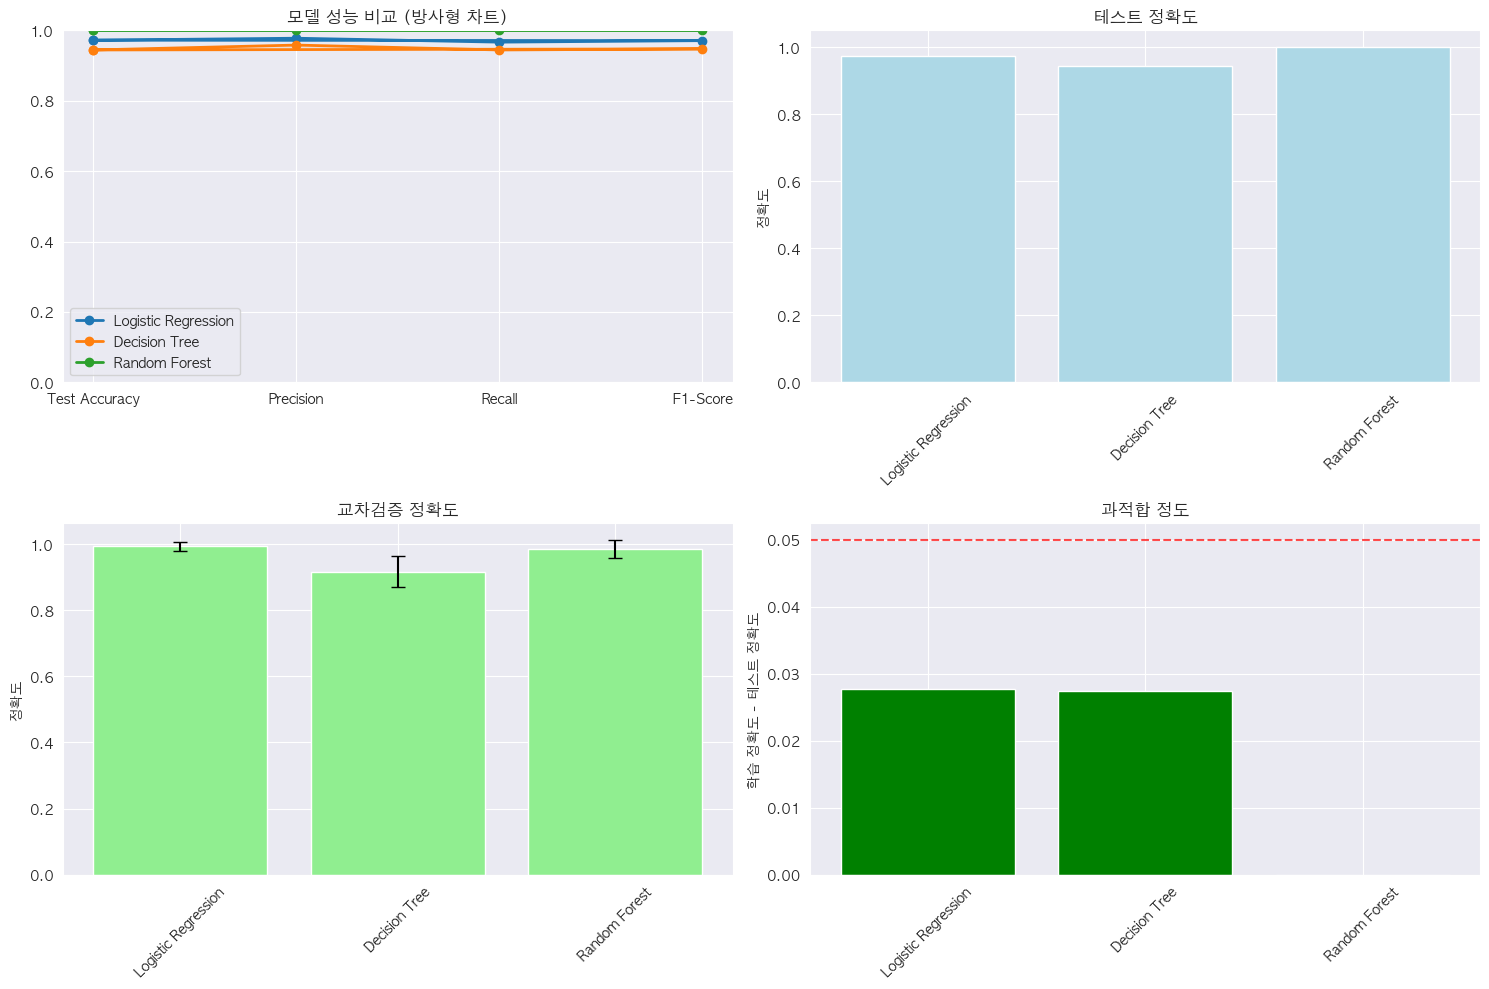


🏆 최고 성능 모델: Random Forest
   테스트 정확도: 1.0000
   F1 스코어: 1.0000


In [20]:
# 시각화
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. 주요 지표 비교 (방사형 차트)
ax = axes[0, 0]
metrics = ["Test Accuracy", "Precision", "Recall", "F1-Score"]

angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
angles += angles[:1]  # 원형 완성

for _, row in df_performance.iterrows():
    values = [row[metric] for metric in metrics]
    values += values[:1]  # 원형 완성
    ax.plot(angles, values, "o-", linewidth=2, label=row["Model"])
    ax.fill(angles, values, alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1)
ax.set_title("모델 성능 비교 (방사형 차트)")
ax.legend()
ax.grid(True)

# 2. 정확도 비교
axes[0, 1].bar(
    df_performance["Model"], df_performance["Test Accuracy"], color="lightblue"
)
axes[0, 1].set_title("테스트 정확도")
axes[0, 1].set_ylabel("정확도")
axes[0, 1].tick_params(axis="x", rotation=45)

# 3. 교차검증 점수 (에러바 포함)
axes[1, 0].bar(
    df_performance["Model"],
    df_performance["CV Mean"],
    yerr=df_performance["CV Std"],
    capsize=5,
    color="lightgreen",
)
axes[1, 0].set_title("교차검증 정확도")
axes[1, 0].set_ylabel("정확도")
axes[1, 0].tick_params(axis="x", rotation=45)

# 4. 과적합 정도
colors_over = ["red" if x > 0.05 else "green" for x in df_performance["Overfitting"]]
axes[1, 1].bar(df_performance["Model"], df_performance["Overfitting"], color=colors_over)
axes[1, 1].axhline(y=0.05, color="red", linestyle="--", alpha=0.7)
axes[1, 1].set_title("과적합 정도")
axes[1, 1].set_ylabel("학습 정확도 - 테스트 정확도")
axes[1, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

# 최고 성능 모델
best_model = df_performance.loc[df_performance["Test Accuracy"].idxmax()]
print(f"\n🏆 최고 성능 모델: {best_model['Model']}")
print(f"   테스트 정확도: {best_model['Test Accuracy']:.4f}")
print(f"   F1 스코어: {best_model['F1-Score']:.4f}")

## 9. 분석 결과 요약

### 📊 주요 인사이트:
1. **와인 데이터는 클래스 간 구분이 명확한 편**
2. **로지스틱 회귀**: 선형 결정 경계, 빠른 학습
3. **결정 트리**: 해석 가능, 비선형 패턴 캐치
4. **랜덤 포레스트**: 앙상블로 높은 일반화 성능
5. **하이퍼파라미터 튜닝으로 성능 개선 가능**

In [21]:
print("\n" + "=" * 60)
print("✅ 분석 완료!")

print("\n📈 주요 인사이트:")
print("1. 와인 데이터는 클래스 간 구분이 명확한 편")
print("2. 로지스틱 회귀: 선형 결정 경계, 빠른 학습")
print("3. 결정 트리: 해석 가능, 비선형 패턴 캐치")
print("4. 랜덤 포레스트: 앙상블로 높은 일반화 성능")
print("5. 하이퍼파라미터 튜닝으로 성능 개선 가능")

print(f"\n🏆 최종 결과:")
print(f"   - 최고 성능 모델: {best_model['Model']}")
print(f"   - 테스트 정확도: {best_model['Test Accuracy']:.4f}")
print(f"   - F1 스코어: {best_model['F1-Score']:.4f}")


✅ 분석 완료!

📈 주요 인사이트:
1. 와인 데이터는 클래스 간 구분이 명확한 편
2. 로지스틱 회귀: 선형 결정 경계, 빠른 학습
3. 결정 트리: 해석 가능, 비선형 패턴 캐치
4. 랜덤 포레스트: 앙상블로 높은 일반화 성능
5. 하이퍼파라미터 튜닝으로 성능 개선 가능

🏆 최종 결과:
   - 최고 성능 모델: Random Forest
   - 테스트 정확도: 1.0000
   - F1 스코어: 1.0000
